# Tiny YOLOv1-style detector on VOC 2007

Train and score the model from this notebook (our PyTorch `TinyYoloV1`, not a third-party package).

- Code: `models/yolo_v1_tiny.py`, `models/yolo_loss.py`, `datasets/voc_yolo.py`
- Data: PASCAL VOC 2007 — first run downloads a chunky zip, so check disk + Wi‑Fi
- Metric: mean **AP@0.5** on the val split (VOC-style)

When you're done training, run the **Plot training curves** cell if you want loss plots saved under `../runs/figures/`.


In [ ]:
# =============================================================================
# Imports  — YOLOv1-style detection on PASCAL VOC 2007 (inline notebook workflow).
# =============================================================================

# json: metrics on disk; sys: PYTHONPATH tweak; time: unique run folder names.
import json
import sys
import time
from collections import defaultdict
from pathlib import Path
from typing import DefaultDict, Dict, List, Tuple


def resolve_repo_root() -> Path:
    """Return the repo root that contains both `models/` and `datasets/` (same idea as LeNet notebook)."""
    cwd = Path.cwd().resolve()
    if (cwd / "models").is_dir() and (cwd / "datasets").is_dir():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "models").is_dir():
        return cwd.parent
    return Path("..").resolve()


REPO_ROOT = resolve_repo_root()
# Hugging Face also publishes a package named `datasets`; prepending REPO_ROOT forces the local folder.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    import torch
except ImportError:
    import subprocess

    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_ROOT / "requirements.txt")]
    )
    import torch

# DataLoader batches images + variable-length labels; torchvision.ops has IoU + NMS primitives.
from torch.utils.data import DataLoader
from torchvision.ops import box_iou, nms
from tqdm import tqdm

# Local VOC wrappers (grid targets for training, full boxes for eval) and class name list.
from datasets import VocYoloEvalDataset, VocYoloGridDataset, voc_eval_collate, voc_yolo_collate
from datasets.voc_yolo import VOC_CLASSES

# Tiny YOLO backbone/head + YOLOv1-style multi-task loss.
from models.yolo_loss import YoloV1Loss
from models.yolo_v1_tiny import TinyYoloV1, boxes_cxcywh_to_xyxy, decode_predictions

# VOC JPEGs + XML land under DATA_ROOT; YOLO_RUN_DIR stores each training run separately from LeNet.
DATA_ROOT = REPO_ROOT / "data"
YOLO_RUN_DIR = REPO_ROOT / "runs" / "yolo"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
YOLO_RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO_ROOT)
print("Dataset cache:", DATA_ROOT)


Repo root: /home/ruhama/Desktop/YOLO
Dataset cache: /home/ruhama/Desktop/YOLO/data


## Hyperparameters


In [3]:
# =============================================================================
# Hyperparameters — VOC images are heavier than MNIST; adjust if VRAM is tight.
# =============================================================================

# EPOCHS: detection usually needs more iterations than tiny MNIST classifiers.
EPOCHS = 40

# BATCH_SIZE: each item is a 224×224 RGB tensor + dense grid targets — lower if CUDA OOM.
BATCH_SIZE = 16

# LR: Adam on a small detector; decrease if loss explodes, increase cautiously if it crawls.
LR = 1e-3

# IMG_SIZE: must match what TinyYoloV1 expects (224 → 7×7 grid with the built-in stride stack).
IMG_SIZE = 224

# GRID: S in the S×S YOLO grid; must match the spatial output size of the network.
GRID = 7

# NUM_WORKERS: JPEG decode + augment is CPU-heavy; 0 is fine on weak machines.
NUM_WORKERS = 4

# SEED: same rationale as LeNet — comparable runs for the write-up.
SEED = 42


## Training


In [4]:
# =============================================================================
# Training — TinyYOLOv1 on PASCAL VOC 2007.
# Each image is resized to IMG_SIZE; each GT box is assigned to one grid cell (see datasets/voc_yolo.py).
# Loss = weighted box regression + objectness + classification (see models/yolo_loss.py).
# =============================================================================

def set_seed(seed: int) -> None:
    """Match LeNet notebook: stabilize RNGs for weights and shuffling."""
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


@torch.no_grad()
def validate(model: torch.nn.Module, criterion: YoloV1Loss, loader: DataLoader, device: torch.device) -> float:
    """Average loss over the val loader — a training health signal; mAP is computed in the next notebook cell."""
    model.eval()
    total = 0.0
    n = 0
    for imgs, gt, obj, cls in loader:
        imgs = imgs.to(device, non_blocking=True)
        # gt: per-cell (cx,cy,w,h) targets in [0,1]; obj: 1 if that cell has a matched object; cls: class index.
        gt = gt.to(device, non_blocking=True)
        obj = obj.to(device, non_blocking=True)
        cls = cls.to(device, non_blocking=True)
        pred = model(imgs)  # (N, 5 + num_classes, GRID, GRID) raw head outputs
        loss, _ = criterion(pred, gt, obj, cls)  # parts dict is only for logging in training
        total += float(loss.item())
        n += 1
    return total / max(n, 1)


set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(VOC_CLASSES)  # 20 PASCAL classes

# Grid dataset: training supervision is sparse — mostly empty cells with low objectness loss.
train_ds = VocYoloGridDataset(DATA_ROOT, "train", img_size=IMG_SIZE, grid_size=GRID)
val_ds = VocYoloGridDataset(DATA_ROOT, "val", img_size=IMG_SIZE, grid_size=GRID)

pin = torch.cuda.is_available()
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=voc_yolo_collate,  # stacks (img, grid_gt, obj_mask, cls_map) batches
    pin_memory=pin,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=voc_yolo_collate,
    pin_memory=pin,
)

model = TinyYoloV1(num_classes=num_classes, grid_size=GRID, in_ch=3).to(device)
criterion = YoloV1Loss(num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

run_name = f"yolo_v1_tiny_{int(time.time())}"
run_path = YOLO_RUN_DIR / run_name
run_path.mkdir(parents=True, exist_ok=True)

best_val = float("inf")
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    steps = 0
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}")
    for imgs, gt, obj, cls in pbar:
        imgs = imgs.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)
        obj = obj.to(device, non_blocking=True)
        cls = cls.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(imgs)
        loss, parts = criterion(pred, gt, obj, cls)
        loss.backward()
        optimizer.step()
        running += float(loss.item())
        steps += 1
        # parts breaks down coord vs cls contributions (scaled); helpful when debugging collapse.
        pbar.set_postfix(loss=f"{running/steps:.3f}", coord=float(parts["coord"]), cls=float(parts["cls"]))

    train_loss = running / max(steps, 1)
    val_loss = validate(model, criterion, val_loader, device)
    row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss}
    history.append(row)
    print(f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f}")

    # Simple model selection: smallest validation loss so far (proxy for good fit).
    if val_loss < best_val:
        best_val = val_loss
        ckpt = {
            "model": model.state_dict(),
            "epoch": epoch,
            "val_loss": val_loss,
            "args": {"data_root": str(DATA_ROOT), "epochs": EPOCHS, "batch_size": BATCH_SIZE},
        }
        torch.save(ckpt, run_path / "best.pt")

with (run_path / "metrics.jsonl").open("w", encoding="utf-8") as f:
    for row in history:
        f.write(json.dumps(row) + "\n")

print(f"Done. Best val loss {best_val:.4f}. Checkpoints in {run_path}")
LAST_YOLO_RUN = run_path


100%|██████████| 460M/460M [15:53<00:00, 482kB/s]    
epoch 1/40: 100%|██████████| 157/157 [00:08<00:00, 18.39it/s, cls=2.18, coord=0.627, loss=62.842]


Epoch 001 | train 62.8417 | val 4.6279


epoch 2/40: 100%|██████████| 157/157 [00:08<00:00, 19.62it/s, cls=2.53, coord=0.514, loss=4.844]


Epoch 002 | train 4.8443 | val 4.0801


epoch 3/40: 100%|██████████| 157/157 [00:08<00:00, 19.39it/s, cls=2.12, coord=1.05, loss=4.532] 


...

Epoch 038 | train 0.6331 | val 5.2177


epoch 39/40: 100%|██████████| 157/157 [00:08<00:00, 19.07it/s, cls=0.744, coord=0.148, loss=0.661]  


Epoch 039 | train 0.6612 | val 5.4135


epoch 40/40: 100%|██████████| 157/157 [00:08<00:00, 19.12it/s, cls=0.307, coord=0.135, loss=0.686]  


Epoch 040 | train 0.6861 | val 5.2971
Done. Best val loss 3.3380. Checkpoints in /home/ruhama/Desktop/YOLO/runs/yolo/yolo_v1_tiny_1778587728


## Evaluation (mAP@0.5)


In [ ]:
# =============================================================================
# Evaluation — mean AP at IoU=0.5 (VOC-style) on the val split.
# Pipeline: forward → decode grid to boxes → threshold → NMS → match to GT → integrate PR curve per class.
# =============================================================================


def decode_image_detections(
    pred: torch.Tensor,
    conf_thres: float,
    nms_thres: float,
    num_classes: int,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Decode one image batch element: return (scores, xyxy boxes, class_ids) after score filter + NMS."""
    # pred shape (1, 5+C, S, S): channels = tx, ty, tw, th, objectness, then C class logits.
    cx, cy, w, h, conf, tcls = decode_predictions(pred)
    cls_prob, cls_id = tcls.softmax(dim=-1).max(dim=-1)  # per cell: best class prob + its index
    score = conf * cls_prob  # joint score — both "objectness" and class confidence must be high
    cx = cx[0].reshape(-1)
    cy = cy[0].reshape(-1)
    w = w[0].reshape(-1)
    h = h[0].reshape(-1)
    score = score[0].reshape(-1)
    cls_id = cls_id[0].reshape(-1)
    keep = score > conf_thres  # remove grid cells the model is unsure about
    if keep.sum() == 0:
        return (
            torch.zeros(0, device=pred.device),
            torch.zeros(0, 4, device=pred.device),
            torch.zeros(0, dtype=torch.long, device=pred.device),
        )
    cx, cy, w, h, score, cls_id = cx[keep], cy[keep], w[keep], h[keep], score[keep], cls_id[keep]
    boxes = boxes_cxcywh_to_xyxy(cx, cy, w, h)  # torchvision NMS expects corner format
    kept_scores: List[torch.Tensor] = []
    kept_boxes: List[torch.Tensor] = []
    kept_cls: List[torch.Tensor] = []
    # Run NMS separately per class so different classes can occupy overlapping image regions.
    for c in range(num_classes):
        m = cls_id == c
        if not m.any():
            continue
        b = boxes[m]
        s = score[m]
        idx = nms(b, s, nms_thres)  # idx = indices of boxes to keep after suppressing overlaps
        kept_boxes.append(b[idx])
        kept_scores.append(s[idx])
        kept_cls.append(torch.full((idx.numel(),), c, device=pred.device, dtype=torch.long))
    if not kept_scores:
        return (
            torch.zeros(0, device=pred.device),
            torch.zeros(0, 4, device=pred.device),
            torch.zeros(0, dtype=torch.long, device=pred.device),
        )
    return torch.cat(kept_scores), torch.cat(kept_boxes), torch.cat(kept_cls)


def compute_ap(
    detections: List[Tuple[int, float, torch.Tensor]],
    gt_by_image_class: Dict[int, torch.Tensor],
    iou_thres: float,
) -> float:
    """One-class AP: sort preds by confidence, assign TP/FP vs GT with greedy IoU matching, VOC envelope integral."""
    if not gt_by_image_class:
        return 0.0
    num_gt = int(sum(g.shape[0] for g in gt_by_image_class.values()))
    if num_gt == 0:
        return 0.0
    if not detections:
        return 0.0
    detections = sorted(detections, key=lambda x: x[1], reverse=True)
    tp = torch.zeros(len(detections))
    fp = torch.zeros(len(detections))
    matched: Dict[int, List[bool]] = defaultdict(list)
    for gi, g in gt_by_image_class.items():
        matched[gi] = [False] * g.shape[0]
    for i, (img_id, score, box) in enumerate(detections):
        gts = gt_by_image_class.get(img_id)
        if gts is None or gts.numel() == 0:
            fp[i] = 1
            continue
        ious = box_iou(box.unsqueeze(0), gts)[0]  # IoU of this box vs all GT of this class on this image
        best_iou, best_j = float(ious.max().item()), int(ious.argmax().item())
        if best_iou >= iou_thres and not matched[img_id][best_j]:
            tp[i] = 1
            matched[img_id][best_j] = True
        else:
            fp[i] = 1
    tp_c = torch.cumsum(tp, dim=0)
    fp_c = torch.cumsum(fp, dim=0)
    rec = tp_c / max(num_gt, 1)
    prec = tp_c / torch.clamp(tp_c + fp_c, min=1e-8)
    # Integrate precision–recall (VOC11-style envelope: non-increasing precision as recall increases).
    mrec = torch.cat([torch.tensor([0.0]), rec, torch.tensor([1.0])])
    mpre = torch.cat([torch.tensor([0.0]), prec, torch.tensor([0.0])])
    for j in range(mpre.numel() - 1, 0, -1):
        mpre[j - 1] = torch.maximum(mpre[j - 1], mpre[j])
    idx = torch.where(mrec[1:] != mrec[:-1])[0]
    if idx.numel() == 0:
        return 0.0
    ap = ((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]).sum().item()
    return float(ap)


# --- post-processing thresholds (it will need finetuning if we see zero detections or hundreds per image) ---
CONF_THRES = 0.15
NMS_THRES = 0.45
IOU_THRES = 0.5
EVAL_BATCH = 8

CKPT_PATH = None

if CKPT_PATH is None:
    ckpts = sorted(YOLO_RUN_DIR.glob("yolo_v1_tiny_*/best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not ckpts:
        raise FileNotFoundError("No YOLO checkpoint found. Run the training cell first.")
    CKPT_PATH = ckpts[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(VOC_CLASSES)
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model = TinyYoloV1(num_classes=num_classes, grid_size=GRID, in_ch=3).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

# Eval dataset keeps every VOC box (training grid version may drop extras in the same cell).
ds = VocYoloEvalDataset(DATA_ROOT, "val", img_size=IMG_SIZE)
loader = DataLoader(
    ds,
    batch_size=EVAL_BATCH,
    shuffle=False,
    num_workers=2,
    collate_fn=voc_eval_collate,  # returns list-of-tensors for boxes (different counts per image)
    pin_memory=torch.cuda.is_available(),
)

dets_per_class: DefaultDict[int, List[Tuple[int, float, torch.Tensor]]] = defaultdict(list)
gt_per_class: DefaultDict[int, Dict[int, torch.Tensor]] = defaultdict(dict)

# Build GT structure: class_id -> {image_index: tensor of xyxy boxes in normalized coords}.
for img_idx in range(len(ds)):
    _, boxes, labels = ds[img_idx]
    if boxes.numel() == 0:
        continue
    for j in range(boxes.shape[0]):
        c = int(labels[j].item())
        b = boxes[j].unsqueeze(0)
        if img_idx not in gt_per_class[c]:
            gt_per_class[c][img_idx] = b
        else:
            gt_per_class[c][img_idx] = torch.cat([gt_per_class[c][img_idx], b], dim=0)

# Run inference: img_id tracks global index across batches for detection–GT alignment.
img_id = 0
with torch.no_grad():
    for imgs, _, _ in tqdm(loader, desc="inference"):
        imgs = imgs.to(device, non_blocking=True)
        preds = model(imgs)
        for b in range(preds.shape[0]):
            s, bx, cid = decode_image_detections(preds[b : b + 1], CONF_THRES, NMS_THRES, num_classes)
            for k in range(s.numel()):
                dets_per_class[int(cid[k].item())].append((img_id + b, float(s[k].item()), bx[k].detach().cpu()))
        img_id += imgs.shape[0]

aps: List[float] = []
for c in range(num_classes):
    ap = compute_ap(dets_per_class[c], gt_per_class[c], IOU_THRES)
    aps.append(ap)
    print(f"AP50 {VOC_CLASSES[c]:12s}: {ap:.4f}")

mean_ap = sum(aps) / max(len(aps), 1)
print(f"Mean AP@0.5 (VOC val, {num_classes} classes): {mean_ap:.4f}")
print(f"Checkpoint: {CKPT_PATH}")


inference: 100%|██████████| 314/314 [00:10<00:00, 29.51it/s]


AP50 aeroplane   : 0.0000
AP50 bicycle     : 0.0045
AP50 bird        : 0.0000
AP50 boat        : 0.0000
AP50 bottle      : 0.0000
AP50 bus         : 0.0022
AP50 car         : 0.0041
AP50 cat         : 0.0013
AP50 chair       : 0.0000
AP50 cow         : 0.0000
AP50 diningtable : 0.0109
AP50 dog         : 0.0001
AP50 horse       : 0.0212
AP50 motorbike   : 0.0014
AP50 person      : 0.0053
AP50 pottedplant : 0.0000
AP50 sheep       : 0.0000
AP50 sofa        : 0.0015
AP50 train       : 0.0162
AP50 tvmonitor   : 0.0013
Mean AP@0.5 (VOC val, 20 classes): 0.0035
Checkpoint: /home/ruhama/Desktop/YOLO/runs/yolo/yolo_v1_tiny_1778587728/best.pt


## Plot training curves

Reads each `../runs/yolo/yolo_v1_tiny_*/metrics.jsonl`, saves a loss PNG under `../runs/figures/<run_name>/` and **shows the plot below**.


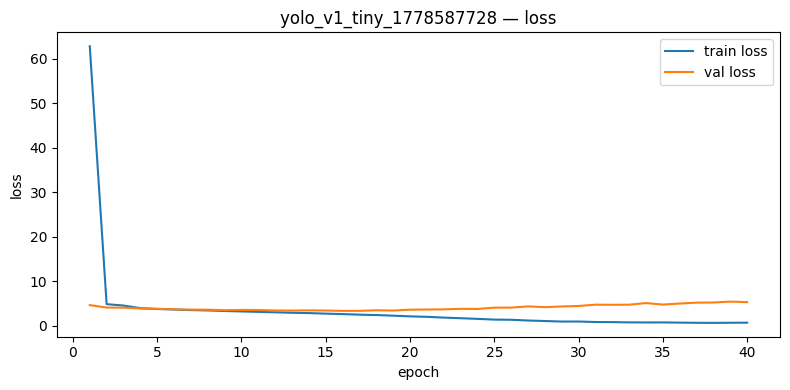

Saved: /home/ruhama/Desktop/YOLO/runs/figures/yolo_v1_tiny_1778587728/curves.png
Figures directory: /home/ruhama/Desktop/YOLO/runs/figures


In [6]:
%matplotlib inline
# =============================================================================
# Plots — train vs validation loss for each completed YOLO run (metrics.jsonl).
# =============================================================================
import matplotlib.pyplot as plt


FIG_DIR = REPO_ROOT / "runs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_jsonl(path):
    """Read JSON lines written by the training cell (one dict per line per epoch)."""
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def plot_yolo_run(rows, out_base, title):
    """Single figure comparing training and validation loss (detection loss scale differs from LeNet CE)."""
    ep = [r["epoch"] for r in rows]
    plt.figure(figsize=(8, 4))
    plt.plot(ep, [r["train_loss"] for r in rows], label="train loss")
    plt.plot(ep, [r["val_loss"] for r in rows], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title} — loss")
    plt.legend()
    plt.tight_layout()
    out_path = out_base.with_suffix(".png")
    plt.savefig(out_path, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", out_path)


metrics_files = sorted(YOLO_RUN_DIR.glob("yolo_v1_tiny_*/metrics.jsonl"))
if not metrics_files:
    print("No YOLO metrics.jsonl under YOLO_RUN_DIR. Run training first.")
else:
    for mf in metrics_files:
        rows = load_jsonl(mf)
        if not rows:
            continue
        if not {"train_loss", "val_loss"}.issubset(rows[0].keys()):
            continue
        run_name = mf.parent.name
        base = FIG_DIR / run_name / "curves"
        base.parent.mkdir(parents=True, exist_ok=True)
        plot_yolo_run(rows, base, title=run_name)
    print("Figures directory:", FIG_DIR)


## After you run this notebook

Export or copy **Mean AP@0.5**, per-class AP lines, **`metrics.jsonl`**, training curves under `runs/figures/`, and note training time / hardware. Those feed the formal results and discussion (strengths, limits, tradeoffs).
